In [30]:
import numpy
import itertools
import matplotlib.pyplot as plt
import matplotlib.patches as ptchs

plt.rcParams.update({'font.size': 14})

eps = 1.125
numpy.random.seed(6876)
homology_dimensions = [ 3, 4, 5, 2, 1 ]

points = numpy.random.randint(0, 10, (25, 2))
points = numpy.unique(points, axis = 0)

def setup_axis(ax, points, e = eps):
    ax.set_aspect('equal')
    for (x, y) in points:
        ax.add_patch(ptchs.Circle((x, y), e, color = 'gray', alpha = 0.2))
    ax.scatter(points[:, 0], points[:, 1], alpha = 0)
    for i, (x, y) in enumerate(points):
        ax.annotate(i, (x, y))

def draw_simplex(ax, points):
    colors = [ None, 'cornflowerblue', 'black', (0, 0, 1, 0.1), (0, 0.75, 0, 0.1), (1, 0, 1, 0.1), (1, 0, 0, 0.1) ]
    color = colors[len(points)]
    if len(points) == 1:
        ax.scatter(points[0][0], points[0][1], 25, color = color)
    else:
        for pts in itertools.permutations(points):
            ax.add_patch(ptchs.Polygon(pts, color = color, linewidth = 0.5))

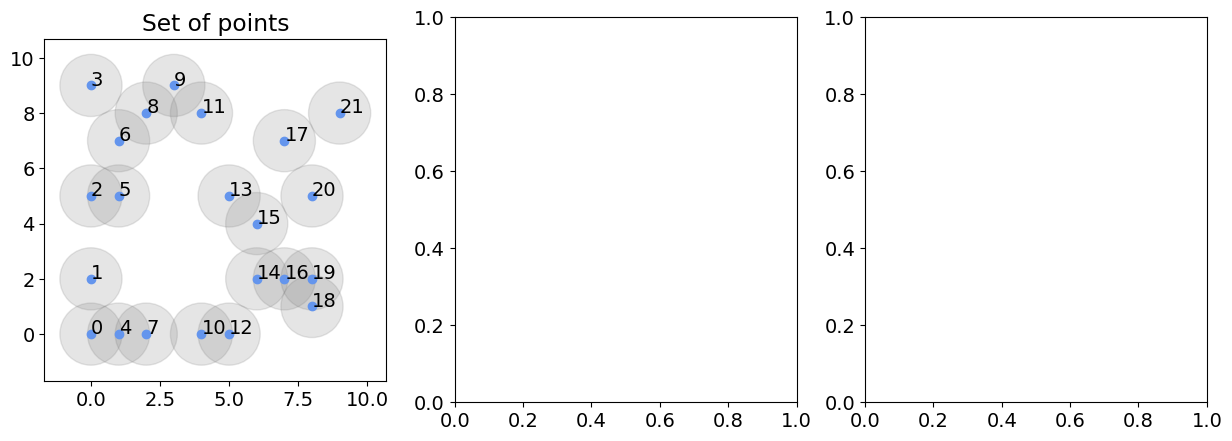

In [31]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

setup_axis(axes[0], points)
axes[0].set_title('Set of points')
axes[0].scatter(points[:, 0], points[:, 1], color = 'cornflowerblue')

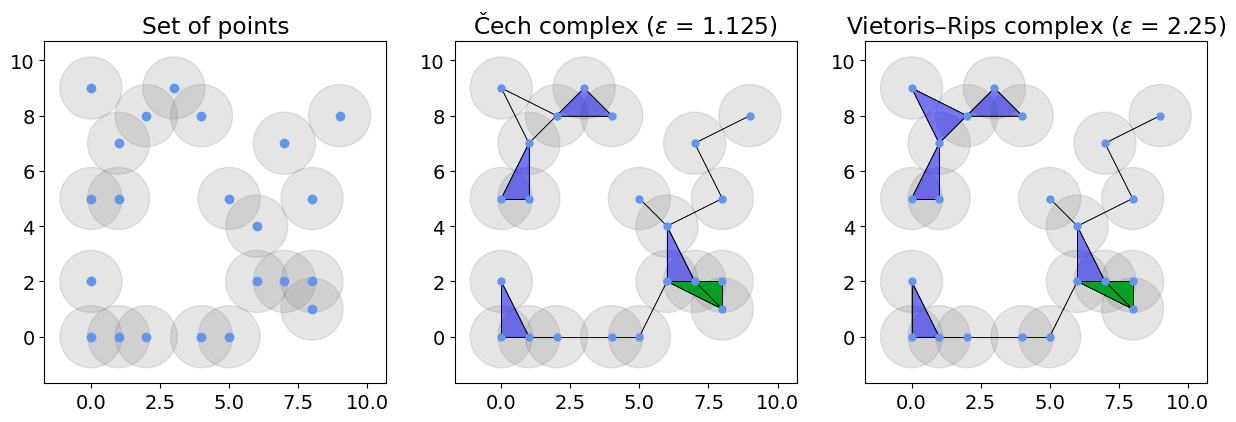

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

setup_axis(axes[0], points)
axes[0].set_title('Set of points')
axes[0].scatter(points[:, 0], points[:, 1], color = 'cornflowerblue')


setup_axis(axes[1], points)
axes[1].set_title(f'Čech complex ($\epsilon$ = {eps})')
for dim in homology_dimensions:
    for pts in itertools.combinations(points, dim):
        pts = numpy.array(pts)
        xmin, xmax = numpy.min(pts[:, 0]), numpy.max(pts[:, 0])
        ymin, ymax = numpy.min(pts[:, 1]), numpy.max(pts[:, 1])
        if (xmax - xmin > 2 * eps) or (ymax - ymin > 2 * eps): continue
        x_range = numpy.arange(xmin - eps, xmax + eps, 0.01)
        y_range = numpy.arange(ymin - eps, ymax + eps, 0.01)
        for (c_x, c_y) in itertools.product(x_range, y_range):
            x_dist = (pts[:, 0] - c_x) ** 2
            y_dist = (pts[:, 1] - c_y) ** 2
            is_ok = (x_dist + y_dist) <= (eps ** 2)
            if (is_ok.all()):
                draw_simplex(axes[1], pts)
                break


setup_axis(axes[2], points)
axes[2].set_title(f'Vietoris–Rips complex ($\epsilon$ = {2 * eps})')
for dim in homology_dimensions:
    for pts in itertools.combinations(points, dim):
        is_simplex = True
        for (x1, y1), (x2, y2) in itertools.product(pts, pts):
            dist = (x2 - x1) ** 2 + (y2 - y1) ** 2
            if dist > (2 * eps) ** 2:
                is_simplex = False
                break
        if is_simplex: draw_simplex(axes[2], pts)

In [2]:
import gtda.homology

gtda.homology.VietorisRipsPersistence(homology_dimensions=[0, 1, 2]).fit_transform_plot([ points ])
None

In [3]:
from gph import ripser_parallel as ripser
ripser(points, maxdim=2, return_generators=True)['dgms']

[array([[0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.       ],
        [0.       , 1.4142135],
        [0.       , 1.4142135],
        [0.       , 1.4142135],
        [0.       , 1.4142135],
        [0.       , 2.       ],
        [0.       , 2.       ],
        [0.       , 2.       ],
        [0.       , 2.       ],
        [0.       , 2.236068 ],
        [0.       , 2.236068 ],
        [0.       , 2.236068 ],
        [0.       , 2.236068 ],
        [0.       , 2.236068 ],
        [0.       , 3.       ],
        [0.       ,       inf]], dtype=float32),
 array([[4.       , 4.2426405],
        [3.1622777, 5.656854 ],
        [2.828427 , 3.       ]], dtype=float32),
 array([], shape=(0, 2), dtype=float32)]

In [4]:
ripser(points, maxdim=2, return_generators=True)['gens'][0]

array([[19, 19, 18],
       [18, 19, 16],
       [16, 16, 14],
       [12, 12, 10],
       [ 7,  7,  4],
       [ 5,  5,  2],
       [ 4,  4,  0],
       [15, 15, 13],
       [11, 11,  9],
       [ 9,  9,  8],
       [ 8,  8,  6],
       [13, 15, 14],
       [10, 10,  7],
       [ 6,  6,  5],
       [ 1,  1,  0],
       [21, 21, 17],
       [20, 20, 17],
       [17, 20, 15],
       [14, 14, 12],
       [ 2,  8,  3],
       [ 3,  2,  1]], dtype=int64)

In [5]:
ripser(points, maxdim=2, return_generators=True)['gens'][1][0]

array([[13,  5, 13,  8],
       [17, 11, 15,  7],
       [17, 13, 20, 13]], dtype=int64)

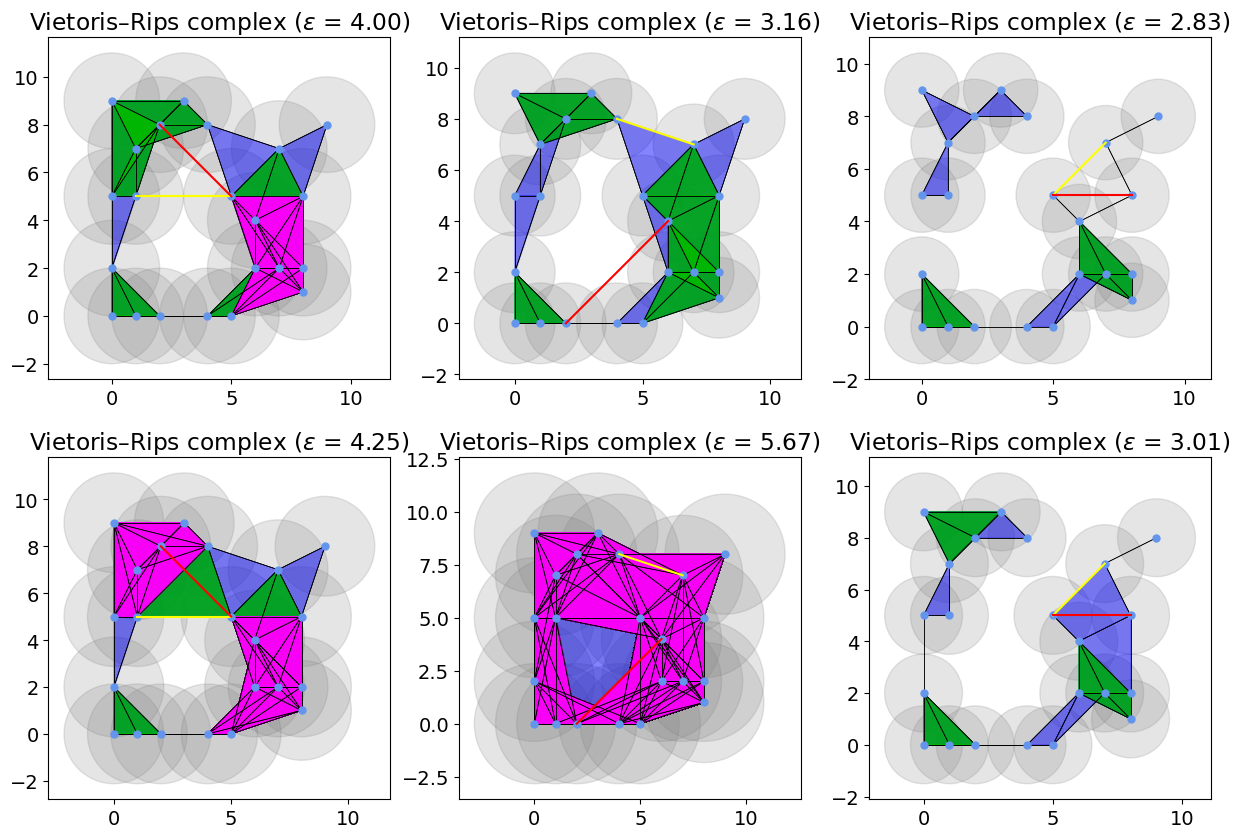

In [18]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

def draw_vr(ax, eps):
    setup_axis(ax, points, eps / 2)
    ax.set_title(f'Vietoris–Rips complex ($\epsilon$ = {eps:.2f})')
    for dim in homology_dimensions:
        for pts in itertools.combinations(points, dim):
            is_simplex = True
            for (x1, y1), (x2, y2) in itertools.product(pts, pts):
                dist = (x2 - x1) ** 2 + (y2 - y1) ** 2
                if dist > eps ** 2:
                    is_simplex = False
                    break
            if is_simplex: draw_simplex(ax, pts)
    
for p, ax1, ax2 in zip(ripser(points, maxdim=2, return_generators=True)['gens'][1][0], axes[0], axes[1]):
    p = [points[t] for t in p]
    ax1.plot([p[0][0], p[1][0]], [p[0][1], p[1][1]], color = 'yellow')
    ax1.plot([p[2][0], p[3][0]], [p[2][1], p[3][1]], color = 'red')
    ax2.plot([p[0][0], p[1][0]], [p[0][1], p[1][1]], color = 'yellow')
    ax2.plot([p[2][0], p[3][0]], [p[2][1], p[3][1]], color = 'red')
    draw_vr(ax1, numpy.linalg.norm(p[0] - p[1]))
    draw_vr(ax2, numpy.linalg.norm(p[2] - p[3]) + 0.01)

In [ ]:
from ripser import ripser

In [35]:
ripser(points, do_cocycles=True)['dgms'][0]

array([[0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.41421354],
       [0.        , 1.41421354],
       [0.        , 1.41421354],
       [0.        , 1.41421354],
       [0.        , 2.        ],
       [0.        , 2.        ],
       [0.        , 2.        ],
       [0.        , 2.        ],
       [0.        , 2.23606801],
       [0.        , 2.23606801],
       [0.        , 2.23606801],
       [0.        , 2.23606801],
       [0.        , 2.23606801],
       [0.        , 3.        ],
       [0.        ,        inf]])

In [37]:
ripser(points, do_cocycles=True)

{'dgms': [array([[0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.        ],
         [0.        , 1.41421354],
         [0.        , 1.41421354],
         [0.        , 1.41421354],
         [0.        , 1.41421354],
         [0.        , 2.        ],
         [0.        , 2.        ],
         [0.        , 2.        ],
         [0.        , 2.        ],
         [0.        , 2.23606801],
         [0.        , 2.23606801],
         [0.        , 2.23606801],
         [0.        , 2.23606801],
         [0.        , 2.23606801],
         [0.        , 3.        ],
         [0.        ,        inf]]),
  array([[4.        , 4.2426405 ],
         [3.1622777 , 5.65685415],
         [2.82842708, 3.        ]])],
 'cocycles': [[],
  [array([[13,  5,  1],
          [11,  5,  1]], dtype=int64),
   array([[17, 11,  1],
       

In [21]:
import numpy as np
from ripser import ripser

# 1. Create a circular point cloud
t = np.linspace(0, 2*np.pi, 20, endpoint=False)
data = np.c_[np.cos(t), np.sin(t)]

# 2. Compute persistence with cocycles enabled
# do_cocycles=True is required to get representative generators
result = ripser(data, do_cocycles=True)
diagrams = result['dgms']
cocycles = result['cocycles']

# 3. Identify the index of the most persistent H1 hole
h1_diagram = diagrams[1]
# Persistence = death - birth
persistence = h1_diagram[:, 1] - h1_diagram[:, 0]
max_idx = np.argmax(persistence)

# 4. Extract the representative (cocycle) for that hole
# Returns an array where each row is [vertex_i, vertex_j, value]
representative_edges = cocycles[1][max_idx]

print("Edges forming the generator (indices and coefficients):")
for edge in representative_edges:
    v1, v2, val = edge.astype(int)
    print(f"Edge: ({v1}, {v2}) with coefficient {val}")

Edges forming the generator (indices and coefficients):
Edge: (1, 0) with coefficient 1
Edge: (19, 1) with coefficient 1
Edge: (2, 0) with coefficient 1
Edge: (19, 2) with coefficient 1
Edge: (18, 1) with coefficient 1
Edge: (3, 0) with coefficient 1
Edge: (19, 3) with coefficient 1
Edge: (18, 2) with coefficient 1
Edge: (17, 1) with coefficient 1
Edge: (4, 0) with coefficient 1
Edge: (19, 4) with coefficient 1
Edge: (18, 3) with coefficient 1
Edge: (17, 2) with coefficient 1
Edge: (16, 1) with coefficient 1
Edge: (5, 0) with coefficient 1
Edge: (19, 5) with coefficient 1
Edge: (18, 4) with coefficient 1
Edge: (17, 3) with coefficient 1
Edge: (16, 2) with coefficient 1
Edge: (15, 1) with coefficient 1
Edge: (6, 0) with coefficient 1
Edge: (18, 5) with coefficient 1
Edge: (17, 4) with coefficient 1
Edge: (16, 3) with coefficient 1
Edge: (15, 2) with coefficient 1
Edge: (14, 1) with coefficient 1
Edge: (12, 5) with coefficient 1


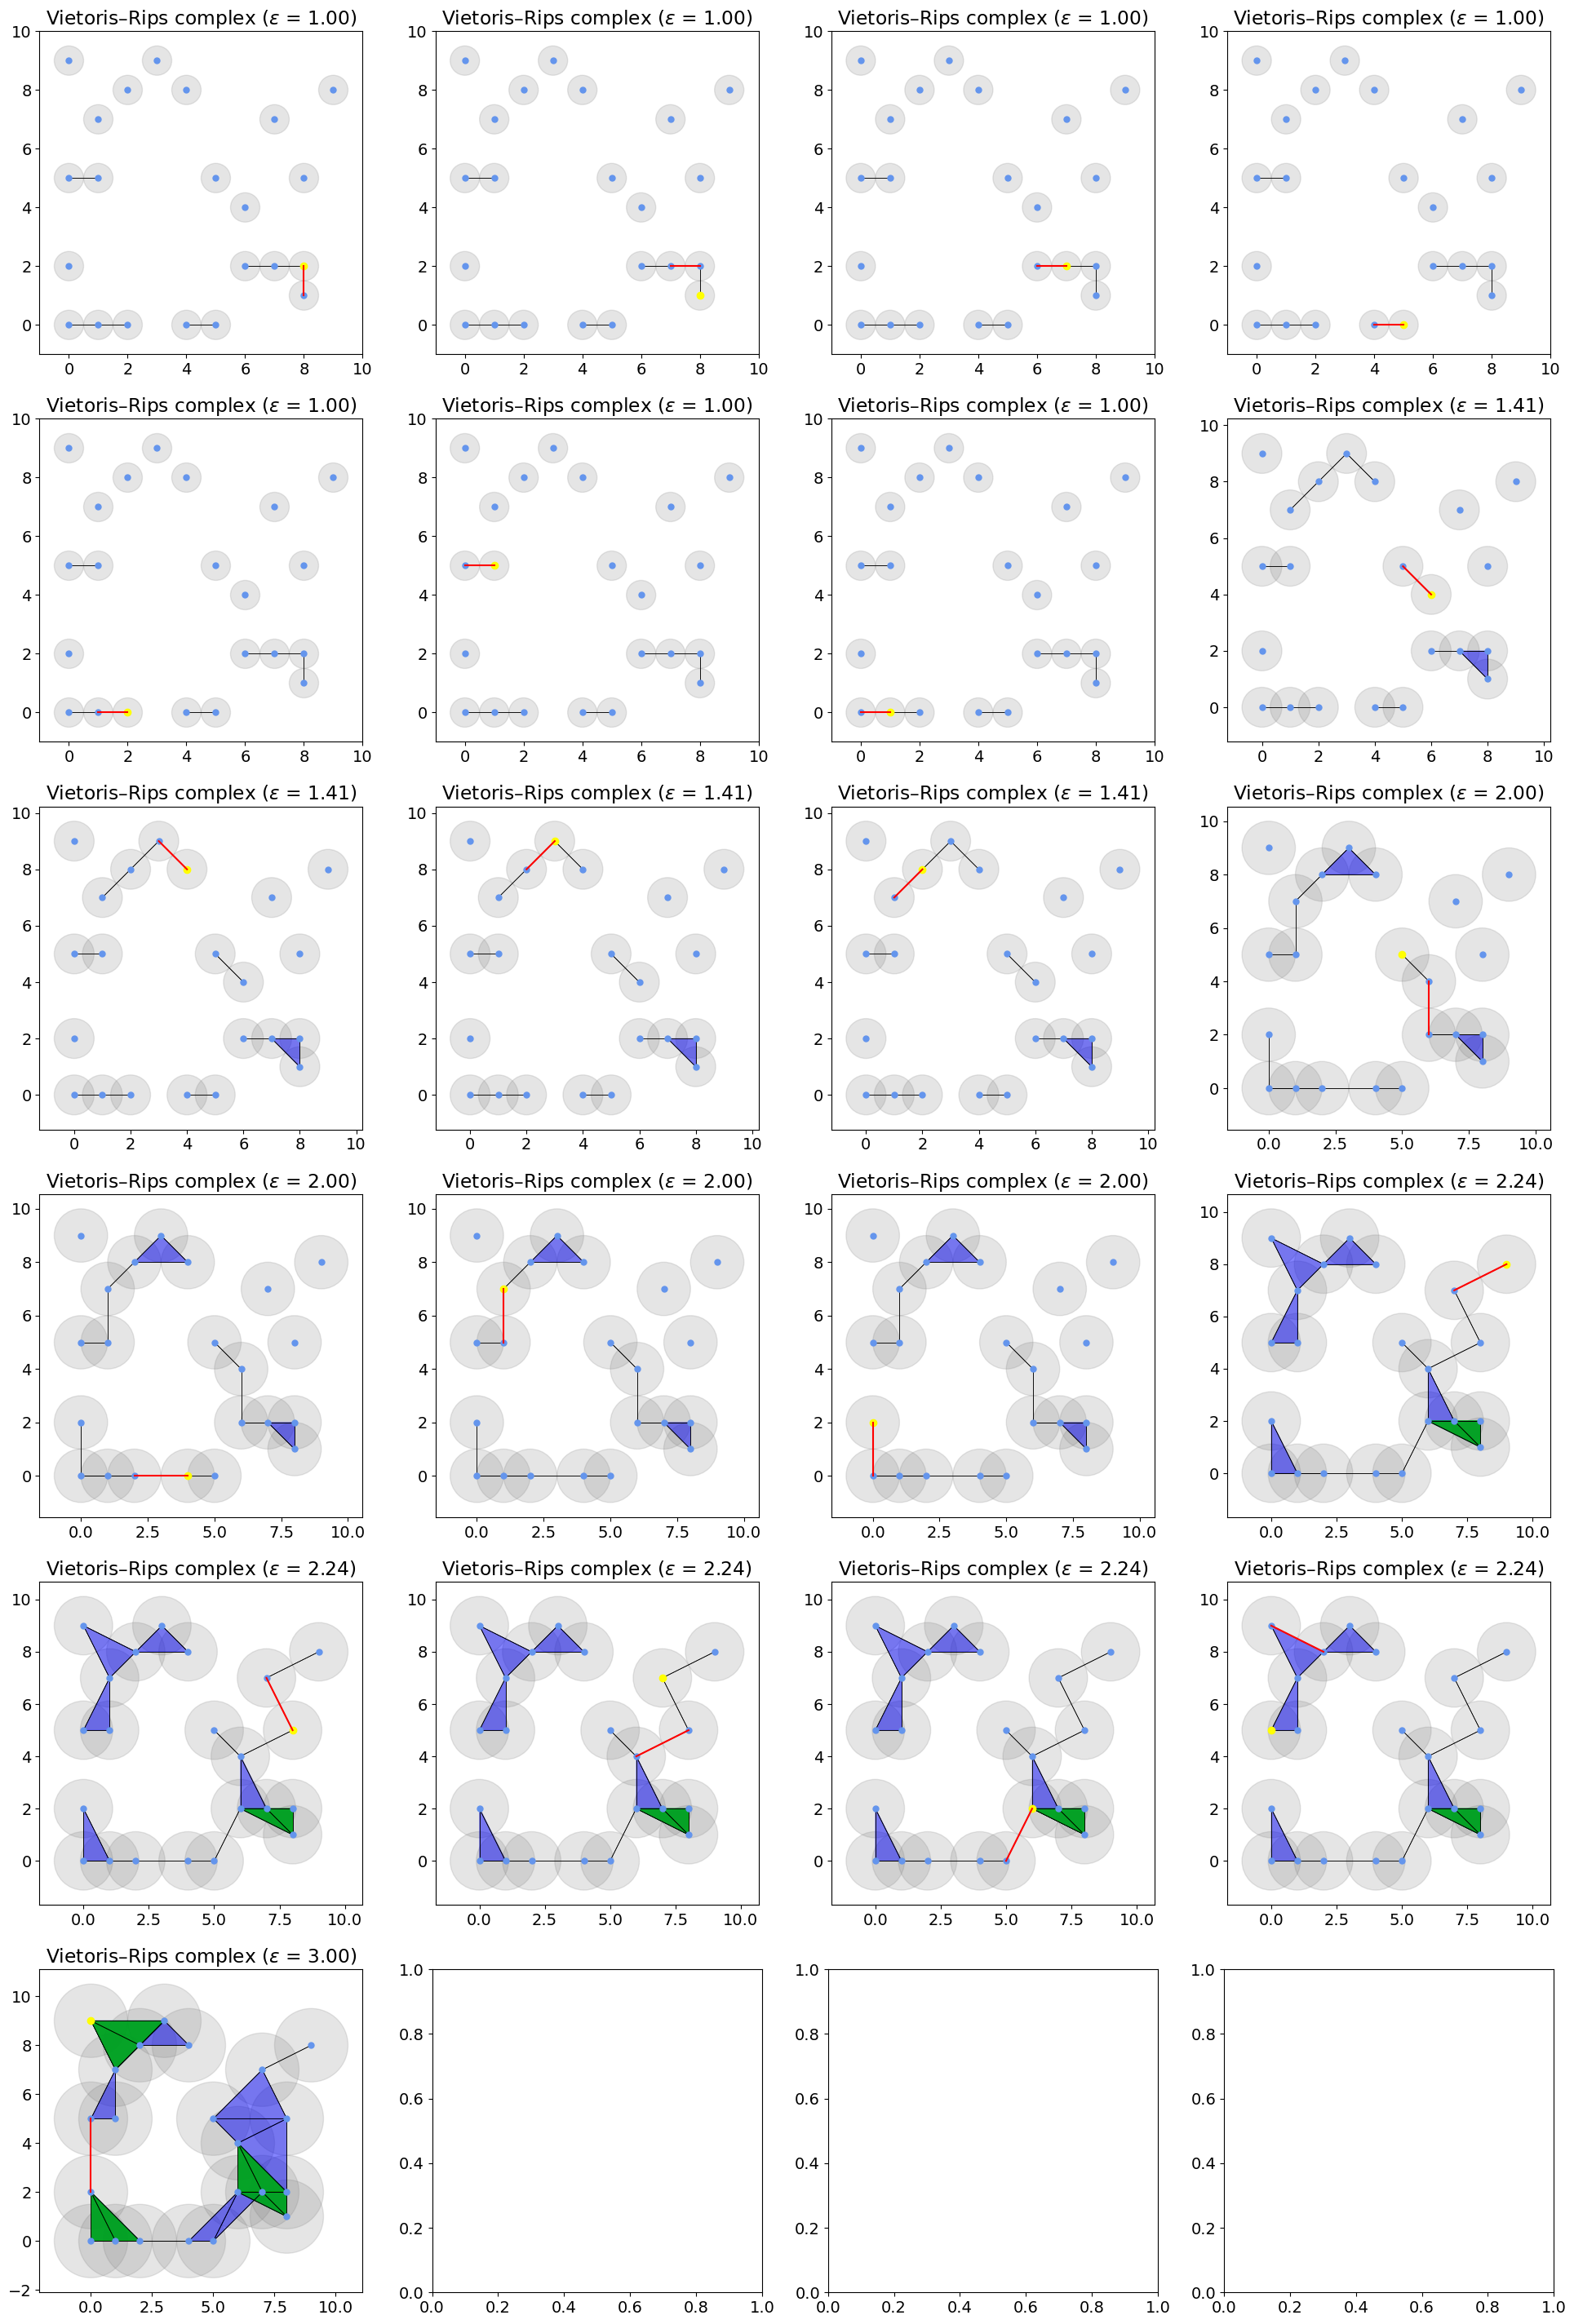

In [15]:
fig, axes = plt.subplots(6, 4, figsize = (24, 36))
    
for p, ax in zip(ripser(points, maxdim=2, return_generators=True)['gens'][0], axes.flat):
    p = [points[t] for t in p]
    draw_vr(ax, numpy.linalg.norm(p[1] - p[2]))
    ax.scatter([p[0][0]], [p[0][1]], color = 'yellow')
    ax.plot([p[1][0], p[2][0]], [p[1][1], p[2][1]], color = 'red')

In [25]:
numpy.linalg.norm(points[13] - points[5]), numpy.linalg.norm(points[13] - points[8])

(4.0, 4.242640687119285)

In [26]:
numpy.linalg.norm(points[17] - points[11]), numpy.linalg.norm(points[15] - points[7])

(3.1622776601683795, 5.656854249492381)

In [27]:
numpy.linalg.norm(points[17] - points[13]), numpy.linalg.norm(points[20] - points[13])

(2.8284271247461903, 3.0)

In [19]:
ripser(points, maxdim=2, return_generators=True)['gens'][2]

array([0], dtype=int64)

In [18]:
ripser(points, maxdim=2, return_generators=True)['gens'][3]

[array([], shape=(0, 2), dtype=int64), array([], shape=(0, 2), dtype=int64)]

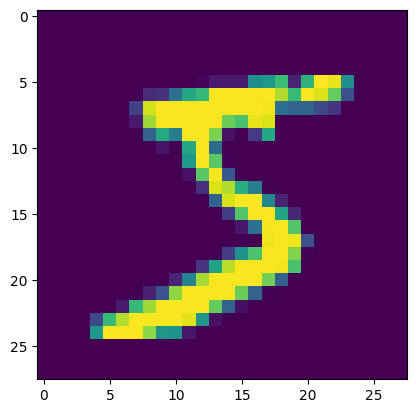

In [2]:
import numpy
import torchvision
import matplotlib.pyplot as plt

train = torchvision.datasets.MNIST("mnist")
img = numpy.array(train[0][0])
plt.imshow(img)

In [3]:
import cvtda.utils

point_cloud = cvtda.utils.image2pointcloud([ img ], 1)[0]
point_cloud.shape

image2pointcloud: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]


(784, 3)

In [4]:
import gtda.plotting

gtda.plotting.plot_point_cloud(point_cloud)

In [5]:
import gtda.homology
from gph import ripser_parallel
from ripser import ripser

vr = gtda.homology.VietorisRipsPersistence(homology_dimensions=[0, 1, 2]).fit_transform([ point_cloud ])[0]
raw_vr = ripser_parallel(point_cloud, maxdim=2, return_generators=True)
ripser_vr = ripser(point_cloud, maxdim=2, do_cocycles=True)

In [6]:
explanations = list(raw_vr['gens'][0]) + ripser_vr['cocycles'][1]
len(explanations)

1323

In [ ]:
raw_vr['gens'][0]

array([645, 672, 644], dtype=int64)

In [20]:
a = [1, 2, 3]
a[:-2], a[-2:]

([1], [2, 3])

In [18]:
raw_vr['gens'][1][1]

array([], shape=(0, 4), dtype=int64)

In [10]:
ripser_vr['cocycles'][1]

[array([[623, 379,   1],
        [623, 180,   1],
        [520, 180,   1]], dtype=int64),
 array([[241, 186,   1]], dtype=int64),
 array([[464, 380,   1],
        [380, 214,   1]], dtype=int64),
 array([[648, 518,   1],
        [648, 434,   1],
        [648, 203,   1],
        [648, 544,   1]], dtype=int64),
 array([[218, 159,   1]], dtype=int64),
 array([[231, 176,   1],
        [176, 153,   1]], dtype=int64),
 array([[519, 319,   1],
        [656, 319,   1],
        [681, 319,   1],
        [519, 157,   1]], dtype=int64),
 array([[176, 159,   1],
        [231, 176,   1],
        [176, 153,   1],
        [176, 154,   1]], dtype=int64),
 array([[629, 348,   1],
        [629, 435,   1],
        [629, 467,   1],
        [629, 321,   1],
        [603, 348,   1],
        [603, 467,   1],
        [603, 321,   1],
        [629, 520,   1]], dtype=int64),
 array([[570, 410,   1]], dtype=int64),
 array([[376, 268,   1],
        [268, 177,   1]], dtype=int64),
 array([[463, 410,   1],
        [5

In [46]:
for (b, d, dim), explanation in tqdm.tqdm(zip(vr, explanations), total = len(vr)):
    if d - b <= 2:
        continue
    break

 51%|█████     | 677/1324 [00:00<00:00, 338605.27it/s]


In [48]:
points = [point_cloud[point] for point in explanation]
death = numpy.linalg.norm(points[1] - points[2])
death

2.23606797749979

In [49]:
mask = numpy.zeros_like(img)

queue = set([tuple(points[0])])
while len(queue) != 0:
    point = queue.pop()
    if mask[point[0], point[1]]:
        continue
    mask[point[0], point[1]] = 1.0
    for other in point_cloud:
        if numpy.linalg.norm(other - point) >= death:
            continue
        if mask[other[0], other[1]] == 1.0:
            continue
        queue.add(tuple(other))

In [64]:
m = numpy.zeros_like(img)

queue = set([tuple(points[0])])
while len(queue) != 0:
    point = queue.pop()
    m[point[0], point[1]] = 1.0
    for other in point_cloud[numpy.linalg.norm(point_cloud - point, axis = 1) < death]:
        if m[other[0], other[1]] == 1.0:
            continue
        queue.add(tuple(other))

(m == mask).all()

True

100%|█████████▉| 1323/1324 [00:36<00:00, 35.91it/s]


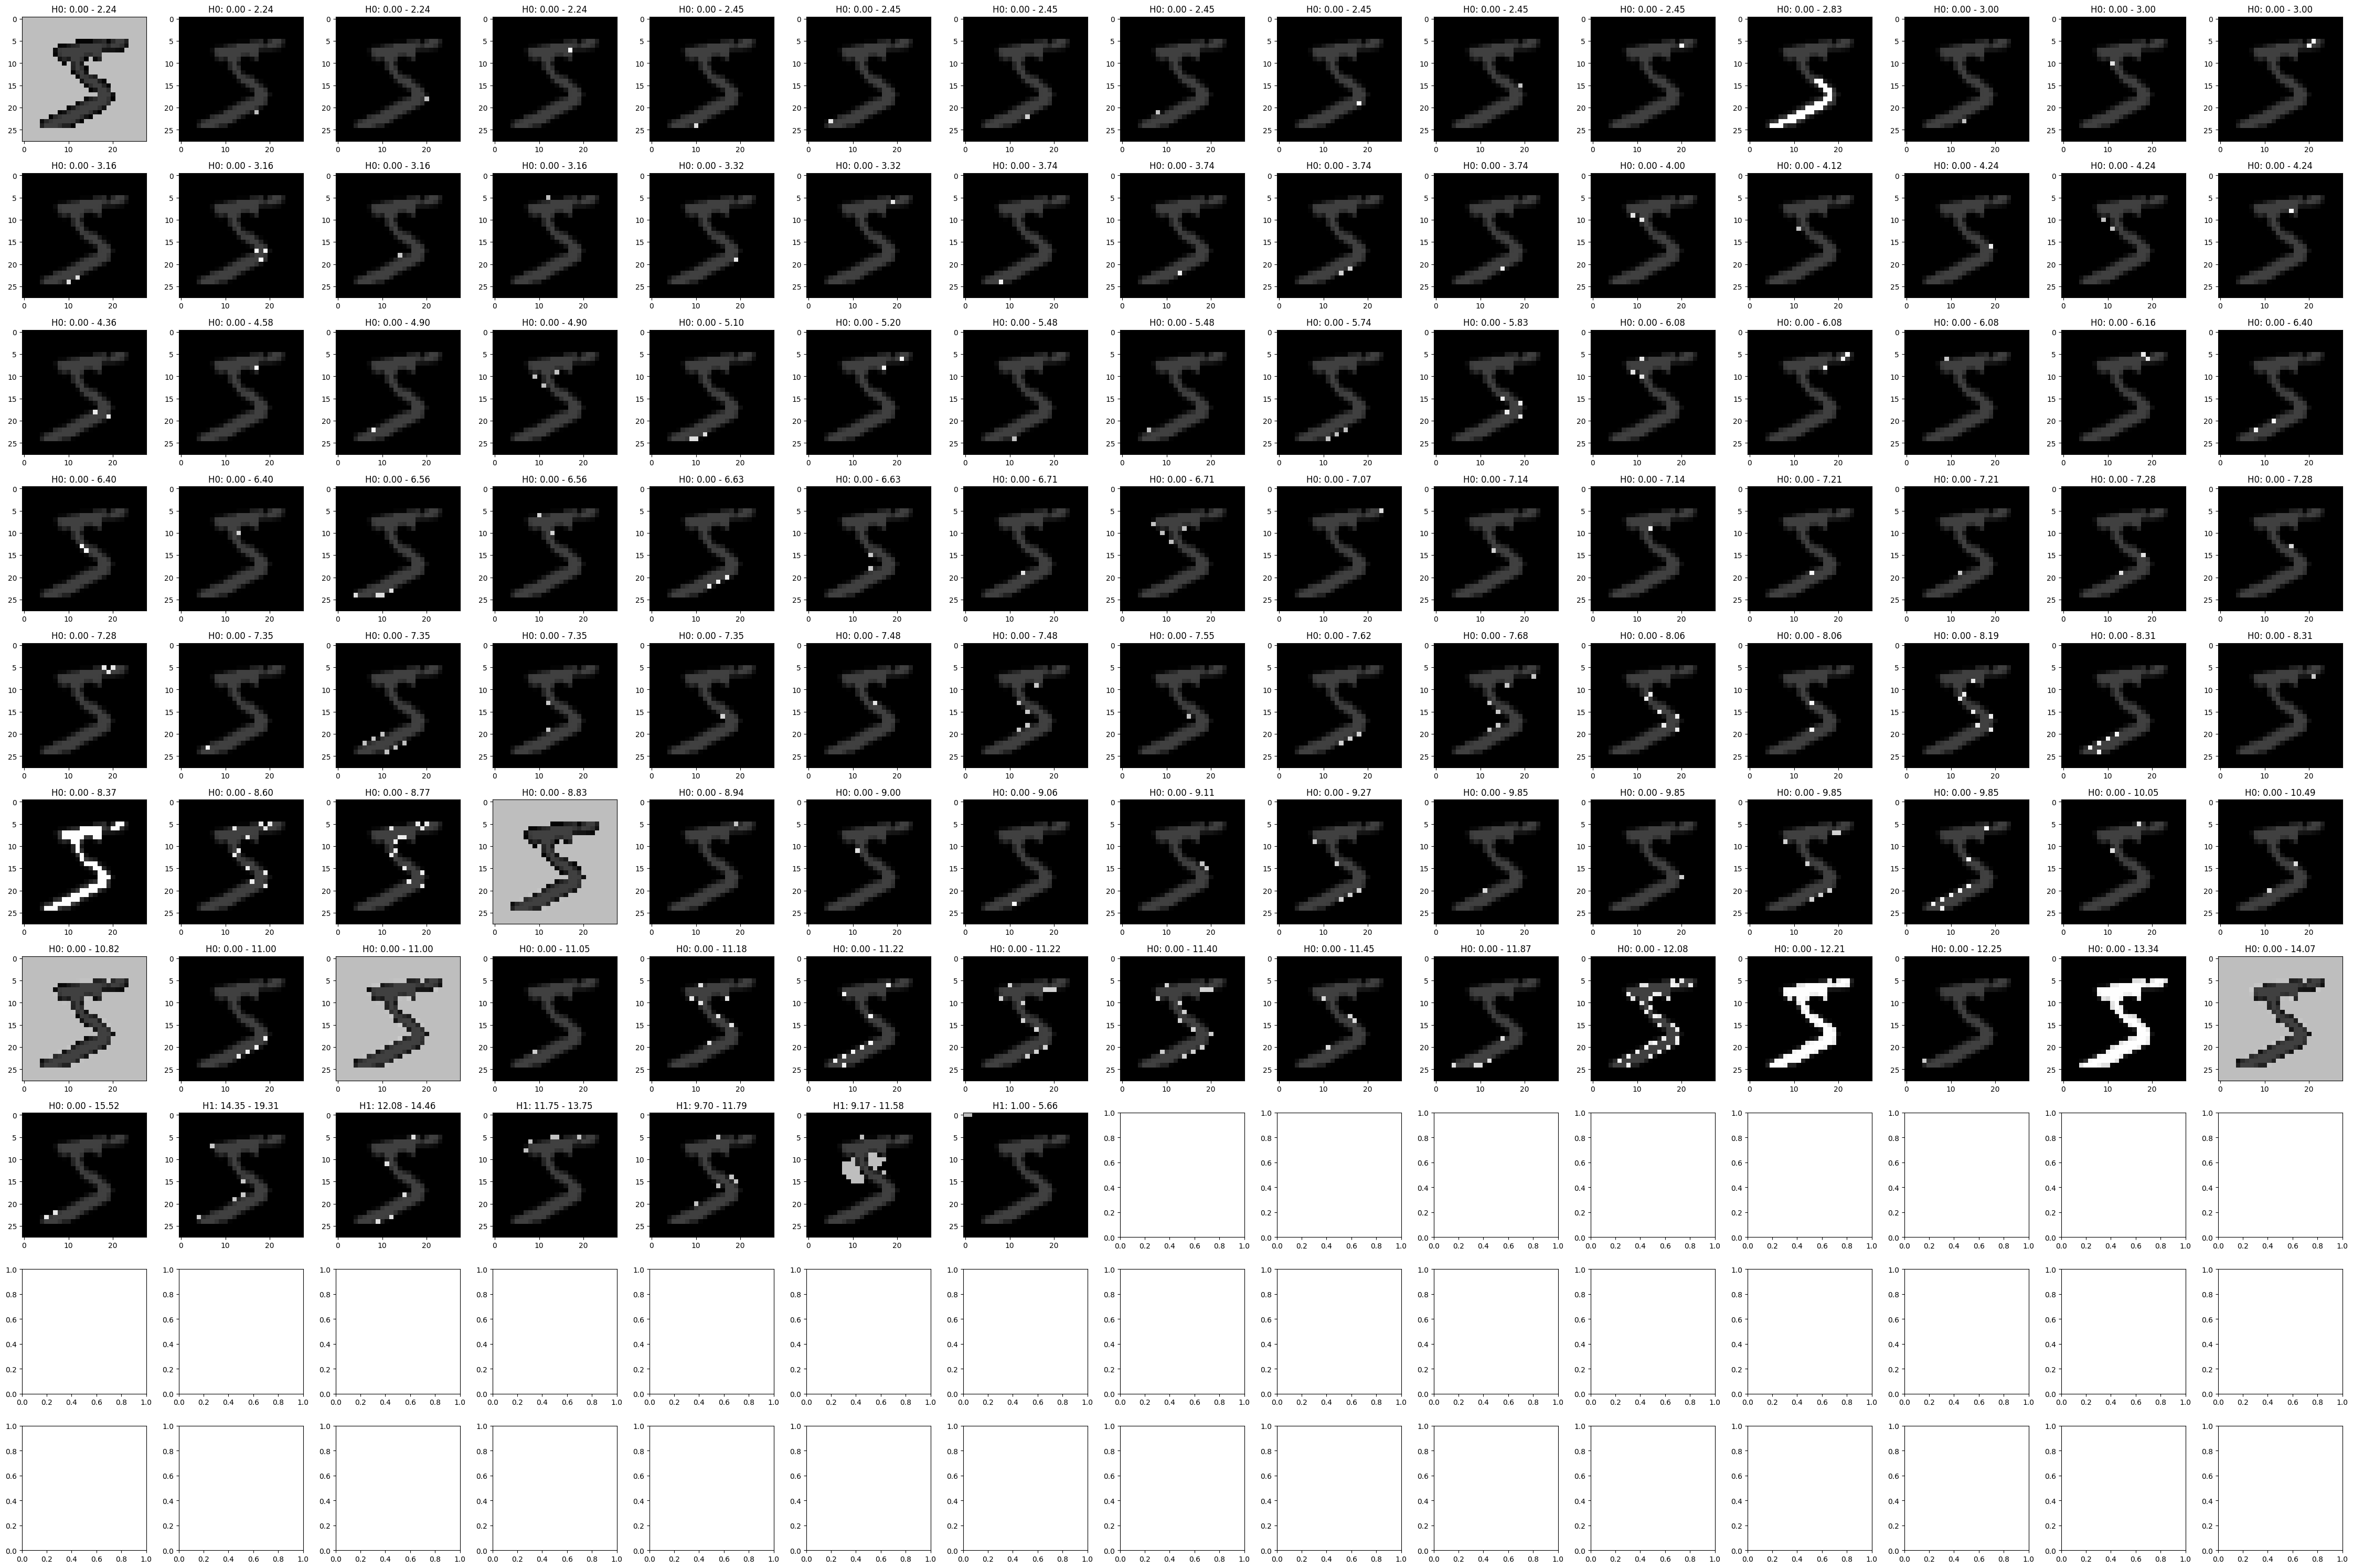

In [44]:
import tqdm

fig, axes = plt.subplots(10, 15, figsize=(45, 30))
cou = 0
for (b, d, dim), explanation in tqdm.tqdm(zip(vr, explanations), total = len(vr)):
    if d - b <= 2:
        continue
    mask = numpy.zeros_like(img)
    if dim == 0:
        points = [point_cloud[point] for point in explanation]
        death = numpy.linalg.norm(points[1] - points[2])
        assert numpy.abs(d - death) < 1e-6, f"{d}, {death}"

        queue = set([tuple(points[0])])
        while len(queue) != 0:
            point = queue.pop()
            if mask[point[0], point[1]]:
                continue
            mask[point[0], point[1]] = 1.0
            for other in point_cloud:
                if numpy.linalg.norm(other - point) >= death:
                    continue
                if mask[other[0], other[1]] == 1.0:
                    continue
                queue.add(tuple(other))
    else:
        points = point_cloud[explanation[:, :2].flatten()][:, :2]
        mask[points[:, 0], points[:, 1]] = 1.0

    axes.flat[cou].imshow(img, cmap="gray")
    axes.flat[cou].imshow(mask, cmap="gray", alpha=0.75)
    axes.flat[cou].set_title(f"H{int(dim)}: {b:.2f} - {d:.2f}")
    cou += 1

fig.tight_layout()
None